Exemplo de código em Python!

In [ ]:
print("Hello world!")

Hello world!


Perceptron

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [ ]:
features = ["MonthlyCharges" , "Contract" , "OnlineSecurity" , "Churn"]
df = df[features]

In [ ]:
df = df.dropna()

In [ ]:
label_encoders = {}
for col in ["Contract" , "OnlineSecurity" , "Churn"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [ ]:
X = df[["MonthlyCharges" , "Contract" , "OnlineSecurity"]]
y = df["Churn"].values

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
class Perceptron:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def activation(self, x):
        return 1 if x >= 0 else 0

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.epochs):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_pred = self.activation(linear_output)

                update = self.lr * (y[idx] - y_pred)
                self.weights += update * x_i
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.array([self.activation(x) for x in linear_output])

In [ ]:
perceptron = Perceptron(lr=0.01, epochs=1000)
perceptron.fit(X_train, y_train)

y_pred = perceptron.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Acurácia: {accuracy:.4f}")
print("Matriz de Confusão: \n", conf_matrix)
print("Relatório de Classificação:\n", report)

Acurácia: 0.7132
Matriz de Confusão: 
 [[1342  197]
 [ 409  165]]
Relatório de Classificação:
               precision    recall  f1-score   support

           0       0.77      0.87      0.82      1539
           1       0.46      0.29      0.35       574

    accuracy                           0.71      2113
   macro avg       0.61      0.58      0.58      2113
weighted avg       0.68      0.71      0.69      2113



Redes Neurais de camada unica

In [ ]:
import numpy as np

In [ ]:
def step(x):
  if x >= 0:
    return 1
  else:
    return 0

In [ ]:
def treinar_perceptron(entradas, saidas, taxa_aprendizagem, epocas):
  pesos = np.random.rand(3)

  for epoca in range(epocas):
    for i in range(len(entradas)):
      soma_ponderada = np.dot(entradas[i], pesos)

      saida = step(soma_ponderada)

      erro = saidas[i] - saida
      pesos += taxa_aprendizagem * erro * entradas[i]

  return pesos

In [ ]:
entradas = np.array([
    [5.1, 3.5, 1.4],
    [4.9, 3.0, 1.4],
    [5.1, 3.6, 1.4],
    [6.4, 3.0, 1.7],
    [6.9, 3.1, 1.5],
    [5.7, 2.5, 1.3],
    [5.8, 2.7, 1.3],
])

In [ ]:
saidas = np.array([0, 0, 0, 1, 1, 2, 2])

taxa_aprendizagem = 0.1
epocas = 300

In [ ]:
treinar_perceptron(entradas, saidas, taxa_aprendizagem, epocas)

array([ 36.20437523, -46.1756386 ,  -7.96878461])

In [ ]:
nova_flor = np.array([5.4, 3.5, 1.5])
soma_ponderada = np.dot(nova_flor, pesos)
saida = step(soma_ponderada)

if saida == 0:
  print("Nova flor classificada como Íris")
elif saida == 1:
  print("Nova flor classificada como Lírio")
else:
  print("Nova flor classificada como Rosa")

NameError: name 'pesos' is not defined

Redes Multicamadas

Exemplo 1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
digits = load_digits()
X = digits.data
y = digits.target

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [38]:
mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(50,), max_iter=1000, random_state=42)

In [39]:
y_pred = mlp.predict(X_test)

In [41]:
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.85      0.92        33
           1       0.39      1.00      0.57        28
           2       1.00      0.67      0.80        33
           3       1.00      0.59      0.74        34
           4       1.00      0.35      0.52        46
           5       0.85      0.87      0.86        47
           6       0.85      0.97      0.91        35
           7       1.00      0.71      0.83        34
           8       0.59      0.90      0.71        30
           9       0.71      0.80      0.75        40

    accuracy                           0.76       360
   macro avg       0.84      0.77      0.76       360
weighted avg       0.85      0.76      0.76       360

Confusion Matrix:
 [[28  0  0  0  0  1  0  0  4  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  5 22  0  0  0  0  0  6  0]
 [ 0  0  0 20  0  1  0  0  3 10]
 [ 0 22  0  0 16  1  6  0  0  1]
 [ 0  3  0  0  0 41  0  0  2  1]


In [45]:
def plot_digits(X, y_true, y_pred=None):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ax in enumerate(axes.flat):
        ax.imshow(X[i].reshape(8, 8), cmap="gray")
        if y_pred is not None:
            ax.set_title(f"True: {y_true[i]} \nPred: {y_pred[i]}")
        else:
            ax.set_title(f"True: {y_true[i]}")
        ax.axis("off")
    plt.show()

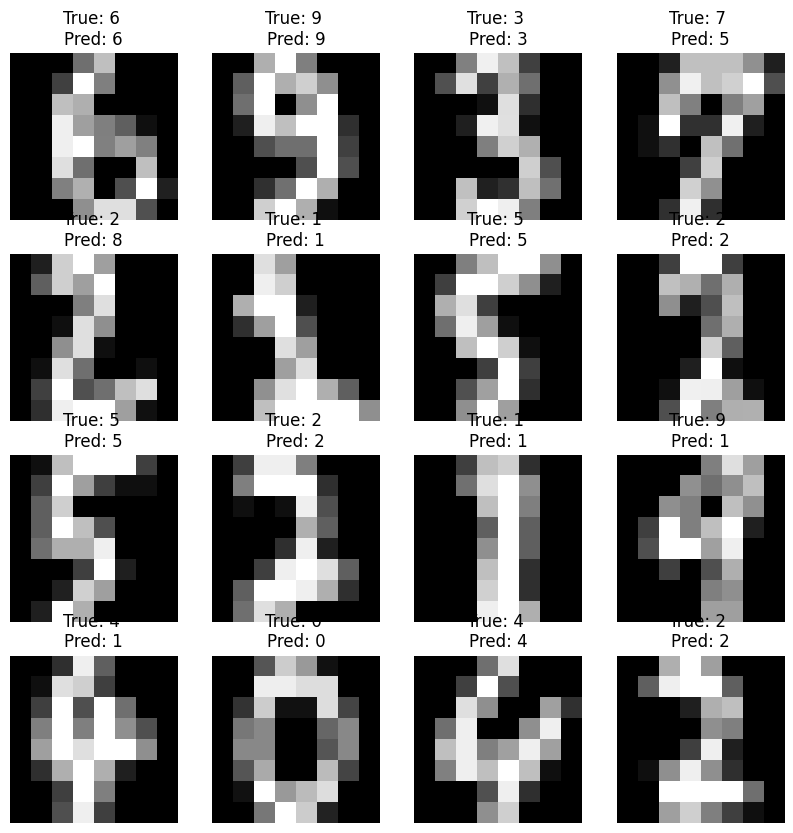

In [46]:
plot_digits(X_test, y_test, y_pred)

Exemplo 2

In [47]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

In [48]:
fashion_mnist = keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [49]:
class_names = ["T-shirt/top" , "Calça" , "Pullover" , "Vestido" , "Casaco" ,
               "Sandália" , "Camisa" , "Tênis" , "Bolsa" , "Bota"]

In [50]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [51]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [52]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [53]:
model.fit(train_images, train_labels, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.7849 - loss: 0.6219
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.8621 - loss: 0.3874
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8739 - loss: 0.3441
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8846 - loss: 0.3147
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8907 - loss: 0.2984


In [55]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("\nAcurácia do testet:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8707 - loss: 0.3533

Acurácia do testet: 0.8680999875068665


In [56]:
predictions = model.predict(test_images)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [57]:
def plot_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = "blue"
    else:
        color = "red"

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                         100 * np.max(predictions_array),
                                         class_names[true_label]),
                                         color=color)

In [58]:
def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)

    thisplot[predicted_label].set_color("red")
    thisplot[true_label].set_color("blue")

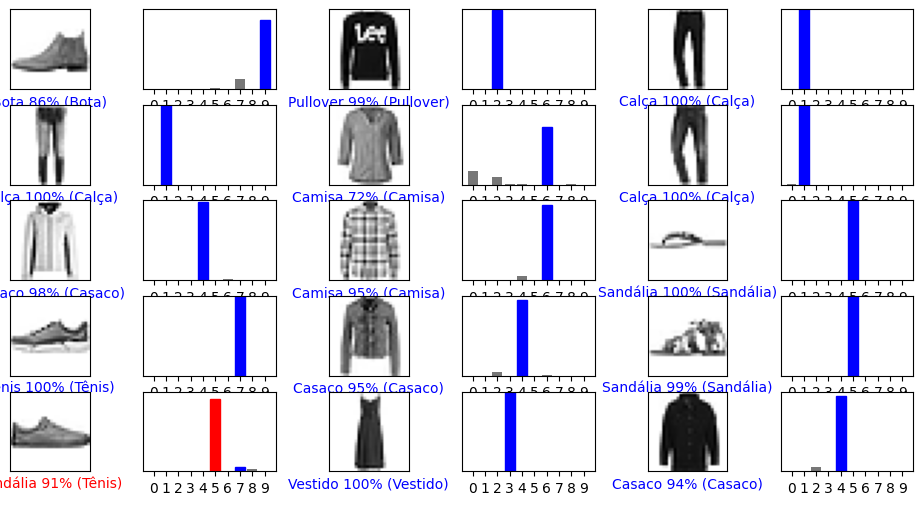

In [59]:
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_cols))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions, test_labels, test_images)
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, predictions, test_labels)
plt.show()